# Datasets: what we have, how good the labels are, and how to split them

Real datasets only. Our generated data is in `synthetic_eda.ipynb`. The static summary is
[`docs/DATASETS.md`](../docs/DATASETS.md), and all logic is in `src/eda/`.

**Run:** `jupyter nbconvert --to notebook --execute --inplace notebooks/datasets_eda.ipynb`

**Layout rule:** every table in §4–§9 is about **one dataset**. Anything that compares datasets is in §10 *Comparisons*,
and its title says what is being compared.

| § | Section |
|---|---|
| 1 | Datasets at a glance (catalogue) |
| 2 | Which file to use |
| 3 | Coding schemes vs the handbooks |
| 4 | `misc.hlqc.gold` (TRAIN) |
| 5 | `misc.miv63a.gold` (TEST) |
| 6 | `annomi.gold` |
| 7 | `welivita.gold` |
| 8 | `miti.casaa.gold` |
| 9 | Unlabelled pools: `pool.hlqc`, `pool.miv63a`, `pool.miv63b` |
| 10 | **Comparisons**: overlaps, same sessions coded by different groups, train vs test, impact on the main model |
| 11 | Splits |
| 12 | Checks |

### Key findings
**`misc.hlqc.gold` (train)**
- FI is a catch-all. 64% of standalone "okay"/"yeah"/"mm-hmm" are coded FI, where the manual says FA. FI is 19% of counsellor utterances (the manual's ceiling is 5%), and only 7% of FI are pleasantries.
- The text is speech-to-text: 78% of gold questions have no "?", and 36% of utterances start mid-sentence.
- Some codes come from one session: GI 75%, DI 75%, ADP 51%.
- SU (9 rows), EC (22) and permission-seeking (1, coded FI) are nearly absent.

**`misc.miv63a.gold` (test)**
- FI means pleasantries here (68%), and FA hardly occurs (0.7%).
- Reflections are long chatbot paraphrases: SR median 18 words.

**`annomi.gold`**
- Strong annotator effect on the same items: the complex-reflection share ranges from 0.19 to 0.82 across annotators.
- Its "open" questions include MISC-closed questions (§10.2), so its OQ/CQ gold is not MISC-consistent.

**Comparisons (§10)**
- Same sessions, HLQC vs AnnoMI experts: client κ 0.36. HLQC calls neutral much of what AnnoMI calls change talk.
- Same session, HLQC vs the CASAA MITI reference: 9 of 16 HLQC "simple" reflections are complex.
- Train vs test: 85% vs 52% of client labels are neutral, and 9% of training counsellor labels (ADW/RCW/WA/CO) never occur in the test.
- Impact on the main model: test SR recall 0.42 (51% → CR); 32% of change/sustain talk predicted neutral; SU 0.39; EC 0.33.

In [1]:
import os, sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src')); os.chdir(ROOT)
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from eda import registry, overlap, clean, splits, stats, quality
pd.set_option('display.max_colwidth', 110); pd.set_option('display.max_rows', 120); pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', font_scale=0.9)
registry.ensure_downloads()
F = registry.load_all()
P = overlap.pairwise(F)
CL = overlap.classify(P, F)
AU = clean.run(F, P); AU.loc[AU.dataset == 'miti.casaa.gold', 'example'] = ''
A = quality.codebook_audit()
MAN = {p.stem: json.load(open(p)) for p in sorted(Path('data/splits').glob('*.json')) if p.stem != 'synthetic'}

# ---- per-dataset helpers: every table below is filtered to ONE dataset ----
def profile(ds, text=True):
    s = {**stats.structure(F[ds]), **(stats.text_quality(F[ds]) if text else {})}
    return pd.Series(s, name=ds).to_frame('value')

def label_table(ds, col):
    lt = stats.label_table(F[ds], col)
    if lt.empty: return
    for spk in sorted(lt.speaker.unique()):
        g = lt[lt.speaker == spk].sort_values('n', ascending=False)
        fig, ax = plt.subplots(figsize=(10, 2.6))
        ax.bar(g.code, g.n, color=['#c44' if t else '#48a' for t in g['is_tail']]); ax.set_yscale('log')
        ax.set_title(f'{ds} | {col} | {spk}  (red = tail: < 1% or < 20)'); ax.tick_params(axis='x', rotation=70, labelsize=7)
        plt.tight_layout(); plt.show()
        print(f'{spk} tail codes:', g[g['is_tail']].code.tolist())

def rules(ds):
    return A[A.dataset == ds].drop(columns='dataset').reset_index(drop=True)

def cleaning(ds):
    a = AU[AU.dataset == ds]
    return a[(a.n > 0) | (a.severity != 'info')].drop(columns='dataset').reset_index(drop=True)

def position(ds, col='t1'):
    pp = stats.position_profile(F[ds], col)
    if len(pp):
        plt.figure(figsize=(9, 2.5)); sns.heatmap(pp.T, cmap='Blues', cbar=False)
        plt.title(f'{ds}: {col} share by session-position decile'); plt.tight_layout(); plt.show()

## 1. Datasets at a glance
A catalogue, one row per dataset. The ID is used everywhere, in code and docs.
- `misc.*` = MISC-coded gold;
- `pool.*` = unlabelled;
- `annomi` / `welivita` / `miti.casaa` = other schemes.

In [2]:
S = {k: stats.structure(v) for k, v in F.items()}
pd.DataFrame([{'id': m.id, 'what it is': m.title, 'role': m.role, 'sessions': S[m.id]['conversations'],
               'units': S[m.id]['rows (units)'], 'coded units': S[m.id]['coded rows'], 'transcript': m.transcription}
              for m in registry.META.values() if m.id in F]).set_index('id')

,what it is,role,sessions,units,coded units,transcript
id,,,,,,
misc.miv63a.gold,"MIBot v6.3A, expert MISC consensus (TEST SET)",fixed test set for all MISC models,10,821,821,none (typed)
misc.hlqc.gold,"HLQC balanced subset, MISC 2.5 (TRAIN SET)",training set for all MISC models; few-shot / synthesis exemplars,10,1925,1925,"ASR (Pérez-Rosas et al. 2019), no casing/punctuation"
pool.hlqc,HLQC full corpus (UNLABELLED pool),"unlabelled pool (retrieval, self-training); contains misc.hlqc.gold",257,30610,0,ASR
pool.miv63a,MIBot v6.3A full run (UNLABELLED pool),unlabelled pool; MUST exclude the 10 test sessions,173,13692,0,none
pool.miv63b,MIBot v6.3B run (UNLABELLED pool),unlabelled pool (self-training v2 'Step F'),165,11771,0,none
annomi.gold,AnnoMI (expert-annotated MI demonstrations),own-scheme train/dev/test; cross-scheme transfer test for MISC models,133,9699,9699,manual (professional)
welivita.gold,Welivita & Pu MI dataset (peer-support forums),own-scheme train/dev/test (agreed subset); weak cross-scheme test; self-training pool,2000,20462,16811,none
miti.casaa.gold,CASAA MITI 4 coded training transcripts,test only (MITI; MISC on 6 exact T2 codes + T1),20,1346,682,manual


## 2. Which file to use
One table per dataset. **Use the file whose *use it for* matches your task.** *Derived from* shows the lineage, so you never count
the same data twice.

In [3]:
for ds, t in registry.FILES.groupby('dataset', sort=False):
    print(f'=== {ds}'); display(t.drop(columns='dataset').set_index('file'))

=== misc.miv63a.gold


,level,labels,use it for,derived from
file,,,,
data/manual/MIV6.3A_manual.csv,utterance,MISC T1/T2 human gold (*_GT) + GPT-4.1 (*_auto),TEST set of every MISC model,pool.miv63a (10 sessions)


=== misc.hlqc.gold


,level,labels,use it for,derived from
file,,,,
data/manual/HLQC_balanced_manual.csv,utterance,MISC T1/T2 human gold,TRAIN set; few-shot exemplars,pool.hlqc (10 sessions)


=== pool.hlqc


...

,level,labels,use it for,derived from
file,,,,
data/external/annomi/AnnoMI-full.csv,turn x annotator,AnnoMI attributes per annotator,agreement analysis (7 ten-rater transcripts),official release (Wu et al.)
data/external/annomi/AnnoMI-simple.csv,turn,AnnoMI main behaviour / talk type,own-scheme train/dev/test,official release
data/AnnoMI.csv,turn,MISC-mapped AnnoMI labels (AutoMISC),source of AnnoMI_eval (different row order),"AnnoMI-full, mapped by AutoMISC"
data/manual/AnnoMI_eval.csv,turn,MISC gold on shared codes only,cross-scheme TEST of MISC models,data/AnnoMI.csv (baseline.prep_crossscheme)
data/parsed/AnnoMI_parsed.csv,utterance,none,utterance-split text,"AnnoMI, parser"


=== welivita.gold


,level,labels,use it for,derived from
file,,,,
data/external/welivita/MI_Dataset.csv,sentence,"ann1, ann2, judge stages, final label",agreement analysis; own-scheme split,official release (Welivita & Pu)
data/external/welivita_mi_parsed.csv,sentence,final label + MISC map (weak_t2),self-training pool,MI_Dataset.csv (selftrain.ingest)
data/manual/Welivita_eval.csv,sentence,MISC gold on shared codes,cross-scheme TEST of MISC models,welivita_mi_parsed.csv (baseline.prep_crossscheme)


=== miti.casaa.gold


,level,labels,use it for,derived from
file,,,,
data/external/casaa/CASAA_eval.csv,utterance,MITI codes + MISC map where exact,MITI / MISC TEST (18 clean sessions),CASAA PDFs (baseline.prep_casaa)
data/external/casaa/casaa_turns.csv,turn,raw code cell + coder notes,audit of the parse,CASAA PDFs
data/external/casaa/casaa_globals.csv,session,MITI global ratings,session-level analysis (9 sessions),CASAA PDFs


Traps:
- `data/HLQC.csv` and `data/parsed/HLQC_parsed.csv` are the unlabelled pool. The **train** set is `data/manual/HLQC_balanced_manual.csv`.
- `data/AnnoMI.csv` is AutoMISC's re-mapped copy, in a **different row order** from the official release. Join on `conv_id` + `utterance_id`.

## 3. Coding schemes vs the handbooks
One table per scheme. The code lists come from the manuals and papers, not the data, so a class we have no data for still shows up.
- **`status`:** `ok` means the code is in the handbook and in our vocabulary.
- **`gold datasets`:** where real examples exist; empty means no real data.

In [4]:
H = registry.handbook_check(F)
ab = {'misc.hlqc.gold':'HLQC','misc.miv63a.gold':'MIV','miti.casaa.gold':'CASAA','welivita.gold':'Welivita','annomi.gold':'AnnoMI'}
H['gold datasets'] = H.datasets_with_examples.map(lambda s: ', '.join(ab[x.strip()] for x in s.split(',') if x.strip() in ab))
for scheme, t in H.groupby('scheme', sort=False):
    print(f'=== {scheme}'); display(t[['speaker','code','manual_group','status','gold datasets']].reset_index(drop=True))
print('MISC 2.5 items we do not use: No Code (NC); reflection valence; globals', registry.HANDBOOK['MISC 2.5']['globals'])

=== MISC 2.5


,speaker,code,manual_group,status,gold datasets
0,counsellor,ADP,MICO,ok,"HLQC, MIV"
1,counsellor,ADW,MIIN,ok,HLQC
2,counsellor,AF,MICO,ok,"HLQC, MIV"
3,counsellor,CO,MIIN,ok,HLQC
4,counsellor,DI,MIIN,ok,"HLQC, MIV"
5,counsellor,EC,MICO,ok,"HLQC, MIV"
6,counsellor,FA,neither,ok,"HLQC, MIV"
7,counsellor,FI,neither,ok,"HLQC, MIV"
8,counsellor,GI,neither,ok,"HLQC, MIV"
9,counsellor,OQ,MICO,ok,"HLQC, MIV"


=== MITI 4.2.1


,speaker,code,manual_group,status,gold datasets
0,counsellor,GI,,ok,CASAA
1,counsellor,Persuade,,ok,CASAA
2,counsellor,Persuade with Permission,,ok,CASAA
3,counsellor,Q,,ok,CASAA
4,counsellor,SR,,ok,CASAA
5,counsellor,CR,,ok,CASAA
6,counsellor,AF,,ok,CASAA
7,counsellor,Seek,,ok,CASAA
8,counsellor,Emphasize,,ok,CASAA
9,counsellor,Confront,,ok,CASAA


=== Welivita (MITI-derived)


,speaker,code,manual_group,status,gold datasets
0,counsellor,Closed Question,,ok,Welivita
1,counsellor,Open Question,,ok,Welivita
2,counsellor,Simple Reflection,,ok,Welivita
3,counsellor,Complex Reflection,,ok,Welivita
4,counsellor,Give Information,,ok,Welivita
5,counsellor,Advise with Permission,,ok,Welivita
6,counsellor,Affirm,,ok,Welivita
7,counsellor,Emphasize Autonomy,,ok,Welivita
8,counsellor,Support,,ok,Welivita
9,counsellor,Advise without Permission,,ok,Welivita


=== AnnoMI


,speaker,code,manual_group,status,gold datasets
0,counsellor,question:open,,ok,AnnoMI
1,counsellor,question:closed,,ok,AnnoMI
2,counsellor,reflection:simple,,ok,AnnoMI
3,counsellor,reflection:complex,,ok,AnnoMI
4,counsellor,input:information,,ok,AnnoMI
5,counsellor,input:advice,,ok,AnnoMI
6,counsellor,input:options,,ok,AnnoMI
7,counsellor,input:negotiation/goal-setting,,ok,AnnoMI
8,counsellor,main:question,,ok,AnnoMI
9,counsellor,main:input,,ok,AnnoMI


MISC 2.5 items we do not use: No Code (NC); reflection valence; globals ['Acceptance', 'Empathy', 'Direction', 'Autonomy Support', 'Collaboration', 'Evocation', 'Self-Exploration (client)']


Crosswalk from each other scheme to MISC (exact concepts only):

In [5]:
for name, t in registry.schemes().items():
    if name != 'MISC 2.5':
        print('===', name); display(t)

=== MITI 4.2.1 (CASAA)


,code,meaning,misc_t1,misc_t2,mapping,source
0,GI,Giving information,IMC,GI,exact,MITI 4.2.1
1,Persuade,Persuade,None,None,none,MITI 4.2.1
2,Persuade with Permission,Persuade with permission,None,None,none,MITI 4.2.1
3,Q,Question (open/closed not split),Q,None,T1 only,MITI 4.2.1
4,SR,Simple reflection,SRL,SR,exact,MITI 4.2.1
5,CR,Complex reflection,CRL,CR,exact,MITI 4.2.1
6,AF,Affirm,CRL,AF,exact,MITI 4.2.1
7,Seek,Seeking collaboration,None,None,none,MITI 4.2.1
8,Emphasize,Emphasizing autonomy,CRL,EC,exact,MITI 4.2.1
9,Confront,Confront,IMI,CO,exact,MITI 4.2.1


=== Welivita MITI-derived


,code,misc_t2,misc_t1,mapping,source
0,Closed Question,CQ,Q,exact,Welivita & Pu 2022 Table 1
1,Open Question,OQ,Q,exact,Welivita & Pu 2022 Table 1
2,Simple Reflection,SR,SRL,exact,Welivita & Pu 2022 Table 1
3,Complex Reflection,CR,CRL,exact,Welivita & Pu 2022 Table 1
4,Give Information,GI,IMC,exact,Welivita & Pu 2022 Table 1
5,Advise with Permission,ADP,IMC,exact,Welivita & Pu 2022 Table 1
6,Affirm,AF,CRL,exact,Welivita & Pu 2022 Table 1
7,Emphasize Autonomy,EC,CRL,exact,Welivita & Pu 2022 Table 1
8,Support,SU,CRL,exact,Welivita & Pu 2022 Table 1
9,Advise without Permission,ADW,IMI,exact,Welivita & Pu 2022 Table 1


=== AnnoMI


,speaker,attribute,subtype,misc,mapping
0,therapist,question,open,OQ,exact
1,therapist,question,closed,CQ,exact
2,therapist,reflection,simple,SR,exact
3,therapist,reflection,complex,CR,exact
4,therapist,input,information,GI,exact
5,therapist,input,advice,ADP/ADW,permission unknown
6,therapist,input,negotiation/goal-setting,None,none
7,therapist,input,options,None,none
8,therapist,other (main behaviour),None,None,none
9,client,change,None,C (T1),T1 only


## 4. `misc.hlqc.gold`: HLQC balanced subset (TRAIN)
10 HLQC sessions (5 high, 5 low quality) with MISC 2.5 labels. This is the training set of every MISC model.

### 4.1 Profile

In [6]:
display(profile('misc.hlqc.gold'))
print('rows per session:', F['misc.hlqc.gold'].groupby('conv_id').size().to_dict())

,value
conversations,10
rows (units),1925
counsellor rows,1040
client rows,885
units / conv (median),228.0
units / conv (min-max),35-318
turns / conv (median),89.5
words / unit (median),8.0
words / unit (p95),24.0
coded rows,1925


rows per session: {'high_001': 35, 'high_099': 276, 'high_117': 173, 'high_121': 318, 'high_127': 109, 'low_001': 227, 'low_026': 229, 'low_031': 260, 'low_033': 230, 'low_080': 68}


### 4.2 Labels

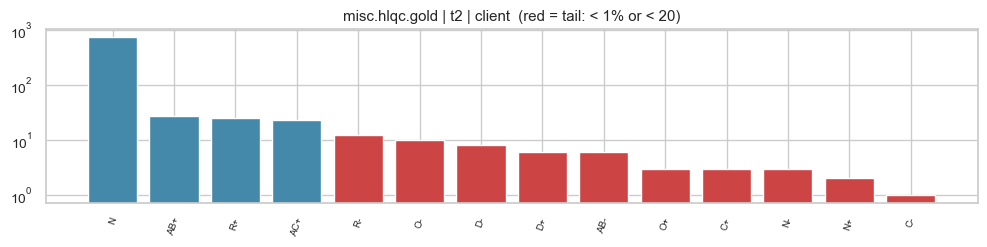

client tail codes: ['R-', 'O-', 'D-', 'D+', 'AB-', 'O+', 'C+', 'N-', 'N+', 'C-']


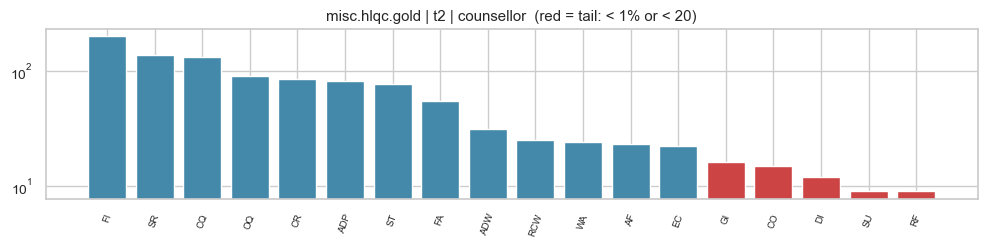

counsellor tail codes: ['GI', 'CO', 'DI', 'SU', 'RF']


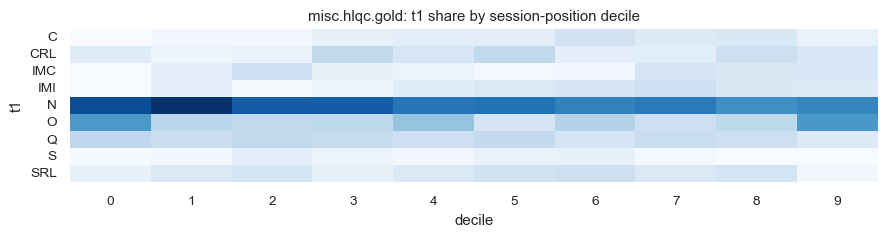

In [7]:
label_table('misc.hlqc.gold', 't2'); position('misc.hlqc.gold')

### 4.3 Codebook rules (MISC 2.5 manual)
Heuristic checks; *flagged* means a candidate violation of the rule quoted in *manual says*.

In [8]:
rules('misc.hlqc.gold')

,rule,manual says,applicable,consistent,flagged,flagged %,flagged label mix,note
0,"standalone acknowledgement ('okay', 'yeah', 'mm-hmm', 'right' ...)","FA (p.22: 'keep-going acknowledgments ... OK, Right, Mm Hmm'); GI if answering a client question",121,44.0,77,63.6,{'FI': 77},
1,share of counsellor utterances coded FI,"FI is rare: 'if these exceed 5% of Counselor responses, they probably are being over-coded' (p.24)",1040,NaN,198,19.0,{},ceiling = 5%
2,"question starting with an auxiliary verb ('do you', 'could you', 'is it' ...)","CQ: 'if the question can be answered by yes/no, it is a closed question'; 'Could you tell me...' = CQ (p.28)",41,40.0,1,2.4,{'OQ': 1},
3,'tell me ...' requests,"OQ ('Tell me more.' / 'Tell me about your family.' = OQ, p.26)",1,1.0,0,0.0,{},exception: 'tell me how old you are' = CQ
4,scaling / ruler questions,"CQ ('On a scale of 1 to 10, how much ...?' = CQ, p.28)",6,6.0,0,0.0,{},
5,utterance ending in '?' coded as a reflection,"a reflection with upward inflection is a (closed) question ('spoiled reflection' = CQ, p.27)",55,53.0,2,3.6,"{'CR': 1, 'SR': 1}",2 of 55 '?'-utterances coded SR/CR
6,short counsellor reply right after a client question,"GI ('Responses to client questions are typically coded as Giving Information, even if brief', p.23)",0,0.0,0,NaN,{},only checkable where the client question has a '?'
7,client ruler answer that is just a number,"0-4 = sustain talk, 5 = FN, 6-10 = change talk (p.40)",0,0.0,0,NaN,{},
8,"permission-seeking ('would it be okay if...', 'do you mind if...', 'can I share...')",EC: 'permission-seeking utterances are coded as a separate utterance of Emphasize Control' (p.16),1,0.0,1,100.0,{'FI': 1},
9,questions (OQ/CQ gold) with no '?' in the text,"(transcript property, not a rule) - the model cannot see the question mark",222,48.0,174,78.4,"{'CQ': 97, 'OQ': 77}",ASR transcripts drop punctuation


### 4.4 What FI contains

In [9]:
quality.fi_content(('misc.hlqc.gold',))

,misc.hlqc.gold (n=198)
acknowledgement (codebook: FA),0.389
other / longer statement,0.348
short fragment (<=3 words),0.197
pleasantry (codebook: FI),0.066


### 4.5 Identical text, different label

In [10]:
it = quality.identical_text('misc.hlqc.gold'); it[it.n_labels > 1]

,speaker,k,n,labels,n_labels,majority share
0,counsellor,okay,34,"{'FI': 24, 'FA': 10}",2,0.71
1,counsellor,yeah,29,"{'FA': 15, 'FI': 14}",2,0.52
2,counsellor,mmhmm,11,"{'FA': 6, 'FI': 5}",2,0.55
3,counsellor,mmhm,7,"{'FI': 5, 'FA': 2}",2,0.71
4,counsellor,yeah yeah,6,"{'FA': 4, 'FI': 2}",2,0.67
5,counsellor,all right,5,"{'FI': 4, 'FA': 1}",2,0.80
6,counsellor,oh,4,"{'FI': 2, 'FA': 2}",2,0.50
7,counsellor,uhhuh,4,"{'FA': 3, 'FI': 1}",2,0.75
8,counsellor,or,3,"{'CQ': 2, 'FI': 1}",2,0.67


### 4.6 Segmentation and reflections

In [11]:
display(quality.segmentation(('misc.hlqc.gold',)))
display(quality.reflection_style(('misc.hlqc.gold',)))

dataset,misc.hlqc.gold
counsellor utterances,1040
utterances per counsellor turn (mean),2.66
turns split into >= 3 utterances %,38.4
utterances <= 3 words %,18.6
utterances starting with and/but/or/so/because %,35.8
reflections that continue a reflection in the same turn %,46.4
SR : CR,137 : 85


,dataset,code,n,median words,>= 15 words %
0,misc.hlqc.gold,SR,137,11.0,30.7
1,misc.hlqc.gold,CR,85,12.0,34.1


### 4.7 Where each code comes from (session concentration)

In [12]:
quality.concentration('misc.hlqc.gold')

,speaker,code,n,sessions,top session,top session share,from low-quality sessions %
0,counsellor,FI,198,10,low_026,0.18,52.0
1,counsellor,SR,137,10,high_121,0.23,40.0
2,counsellor,CQ,132,10,high_099,0.27,46.0
3,counsellor,OQ,90,8,high_099,0.26,41.0
4,counsellor,CR,85,6,low_026,0.34,49.0
5,counsellor,ADP,81,6,low_031,0.51,78.0
6,counsellor,ST,76,7,high_117,0.30,38.0
7,counsellor,FA,55,6,low_026,0.31,51.0
8,counsellor,ADW,31,4,low_031,0.48,100.0
9,counsellor,RCW,25,5,low_001,0.44,96.0


### 4.8 Cleaning issues

In [13]:
display(cleaning('misc.hlqc.gold'))
t1_of = clean.misc_vocab(); h = F['misc.hlqc.gold']
print('Rows whose T1 contradicts the T2 group (needs a decision):')
h[[t1_of.get((s, c)) not in (None, t) for s, c, t in zip(h.speaker, h.t2, h.t1)]][['conv_id','utt_idx','speaker','text','t1','t2']]

,check,n,share,example,severity,action
0,consecutive identical utterances (same speaker),6,0.0031,['yeah'],info,inspect
1,no casing (ASR signal),1107,0.5751,,info,expected for ASR corpora
2,no punctuation (ASR signal),1531,0.7953,,info,expected for ASR corpora
3,T1 inconsistent with T2 group,6,0.0031,Q/ST,error,fix in derived copy
4,short utterances (>=3 occurrences) with conflicting T2,9,0.3333,"'okay', 'yeah', 'mmhmm'",warn,"annotation noise: report, do not relabel"
5,"row count vs paper (1,924)",1,0.0005,1925 rows,info,"ok: off-by-one, likely a header/trailing row in the paper count"


Rows whose T1 contradicts the T2 group (needs a decision):


,conv_id,utt_idx,speaker,text,t1,t2
453,high_117,142,counsellor,so how does that sound to you?,Q,ST
604,high_121,120,counsellor,"I just wanna say we, we can go over some things that are potential to talk about to really focus on that m...",CRL,ST
809,high_127,7,counsellor,so let's talk more about what brought you in today,O,OQ
1523,low_031,156,counsellor,tell me a little bit about those,O,OQ
1546,low_031,179,counsellor,where would you put yourself on how important this is to you,O,CQ
1547,low_031,180,counsellor,want to say on a scale of one to ten just just on importance,O,CQ


**Takeaway (HLQC)**
- FI is used for acknowledgements and fragments, against the manual: it is 4x the ceiling, and 64% of acknowledgements are coded FI.
- Question coding follows the manual (CQ for "do/could/is…", scale questions).
- The text is speech-to-text, cut mid-sentence, and mostly without "?".
- Several codes depend on a single session.

## 5. `misc.miv63a.gold`: MIBot v6.3A expert consensus (TEST)
10 chatbot sessions (an LLM counsellor with real smokers) with MISC 2.5 consensus labels. This is the fixed test set.

### 5.1 Profile

In [14]:
profile('misc.miv63a.gold')

,value
conversations,10
rows (units),821
counsellor rows,580
client rows,241
units / conv (median),78.5
units / conv (min-max),37-119
turns / conv (median),32.5
words / unit (median),12.0
words / unit (p95),25.0
coded rows,821


### 5.2 Labels

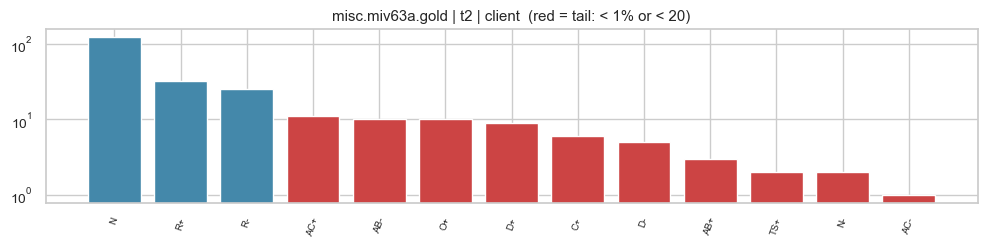

client tail codes: ['AC+', 'AB-', 'O+', 'D+', 'C+', 'D-', 'AB+', 'TS+', 'N-', 'AC-']


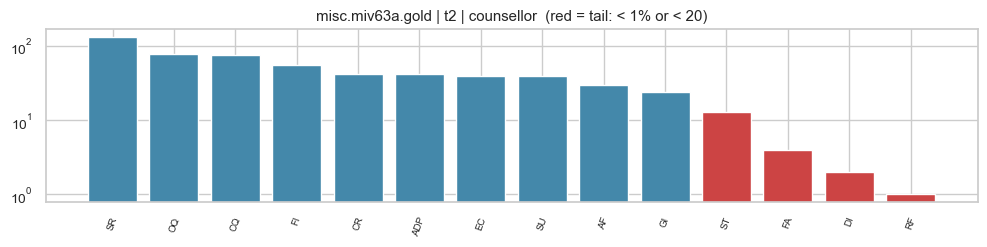

counsellor tail codes: ['ST', 'FA', 'DI', 'RF']


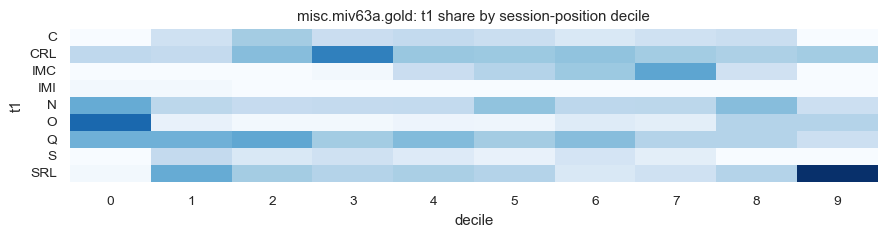

In [15]:
label_table('misc.miv63a.gold', 't2'); position('misc.miv63a.gold')

### 5.3 Codebook rules (MISC 2.5 manual)

In [16]:
rules('misc.miv63a.gold')

,rule,manual says,applicable,consistent,flagged,flagged %,flagged label mix,note
0,"standalone acknowledgement ('okay', 'yeah', 'mm-hmm', 'right' ...)","FA (p.22: 'keep-going acknowledgments ... OK, Right, Mm Hmm'); GI if answering a client question",5,2.0,3,60.0,{'FI': 3},
1,share of counsellor utterances coded FI,"FI is rare: 'if these exceed 5% of Counselor responses, they probably are being over-coded' (p.24)",580,NaN,56,9.7,{},ceiling = 5%
2,"question starting with an auxiliary verb ('do you', 'could you', 'is it' ...)","CQ: 'if the question can be answered by yes/no, it is a closed question'; 'Could you tell me...' = CQ (p.28)",60,60.0,0,0.0,{},
3,'tell me ...' requests,"OQ ('Tell me more.' / 'Tell me about your family.' = OQ, p.26)",1,1.0,0,0.0,{},exception: 'tell me how old you are' = CQ
4,scaling / ruler questions,"CQ ('On a scale of 1 to 10, how much ...?' = CQ, p.28)",0,0.0,0,NaN,{},
5,utterance ending in '?' coded as a reflection,"a reflection with upward inflection is a (closed) question ('spoiled reflection' = CQ, p.27)",159,158.0,1,0.6,{'SR': 1},1 of 159 '?'-utterances coded SR/CR
6,short counsellor reply right after a client question,"GI ('Responses to client questions are typically coded as Giving Information, even if brief', p.23)",0,0.0,0,NaN,{},only checkable where the client question has a '?'
7,client ruler answer that is just a number,"0-4 = sustain talk, 5 = FN, 6-10 = change talk (p.40)",0,0.0,0,NaN,{},
8,"permission-seeking ('would it be okay if...', 'do you mind if...', 'can I share...')",EC: 'permission-seeking utterances are coded as a separate utterance of Emphasize Control' (p.16),4,3.0,1,25.0,{'CQ': 1},
9,questions (OQ/CQ gold) with no '?' in the text,"(transcript property, not a rule) - the model cannot see the question mark",154,151.0,3,1.9,{'OQ': 3},ASR transcripts drop punctuation


### 5.4 What FI contains

In [17]:
quality.fi_content(('misc.miv63a.gold',))

,misc.miv63a.gold (n=56)
pleasantry (codebook: FI),0.679
other / longer statement,0.250
acknowledgement (codebook: FA),0.054
short fragment (<=3 words),0.018


### 5.5 Identical text, different label

In [18]:
quality.identical_text('misc.miv63a.gold', 2).query('n_labels > 1')

,speaker,k,n,labels,n_labels,majority share
0,counsellor,i'm glad to hear that,4,"{'FI': 2, 'AF': 1, 'SU': 1}",3,0.50
1,counsellor,great,4,"{'FI': 3, 'FA': 1}",2,0.75
2,counsellor,that's perfectly fine,2,"{'FI': 1, 'SU': 1}",2,0.50


### 5.6 Segmentation and reflections

In [19]:
display(quality.segmentation(('misc.miv63a.gold',)))
display(quality.reflection_style(('misc.miv63a.gold',)))

dataset,misc.miv63a.gold
counsellor utterances,580
utterances per counsellor turn (mean),3.79
turns split into >= 3 utterances %,92.2
utterances <= 3 words %,4.3
utterances starting with and/but/or/so/because %,0.5
reflections that continue a reflection in the same turn %,47.2
SR : CR,134 : 42


,dataset,code,n,median words,>= 15 words %
0,misc.miv63a.gold,SR,134,18.0,73.1
1,misc.miv63a.gold,CR,42,15.5,57.1


### 5.7 Session outcomes (from the MIV6.3A survey file)

In [20]:
o = registry.miv_outcomes('A'); test = set(F['misc.miv63a.gold'].conv_id); ot = o[o.conv_id.isin(test)]
cols = ['pre_importance','post_importance','pre_confidence','post_confidence','pre_readiness','post_readiness','delta_confidence']
print('the 10 test sessions:'); display(ot[cols].describe().T[['count','mean','std']].round(2))

the 10 test sessions:


,count,mean,std
pre_importance,10.0,5.7,2.50
post_importance,10.0,6.4,2.88
pre_confidence,10.0,3.1,2.02
post_confidence,10.0,5.0,2.71
pre_readiness,10.0,5.9,2.77
post_readiness,10.0,6.0,2.83
delta_confidence,10.0,1.9,1.85


**Takeaway (MIV test)**
- FI here means pleasantries, as the manual intends, but it is still 9.7% of counsellor utterances, above the 5% ceiling.
- Reflections are long, polished paraphrases.
- Questions carry "?".

## 6. `annomi.gold`: AnnoMI expert-annotated MI demonstrations
133 professionally transcribed demo videos in the AnnoMI scheme. 126 transcripts have one annotator; 7 were coded by all 10.

### 6.1 Profile

In [21]:
an = F['annomi.gold']; display(profile('annomi.gold'))
sess = an.groupby('conv_id').agg(quality=('mi_quality','first'), topic=('topic','first'))
print('MI quality:', sess.quality.value_counts().to_dict()); display(sess.topic.value_counts().head(10).to_frame('transcripts'))

,value
conversations,133
rows (units),9699
counsellor rows,4882
client rows,4817
units / conv (median),47.0
units / conv (min-max),6-598
turns / conv (median),47.0
words / unit (median),9.0
words / unit (p95),57.0
coded rows,9699


MI quality: {'high': 110, 'low': 23}


,transcripts
topic,
reducing alcohol consumption,23
smoking cessation,19
taking medicine / following medical procedure,8
reducing recidivism,7
more exercise / increasing activity,7
reducing drug use,7
weight loss,6
unidentifiable,5
asthma management,5


### 6.2 Labels

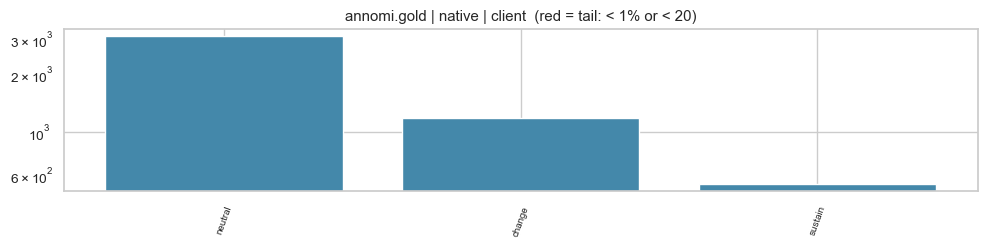

client tail codes: []


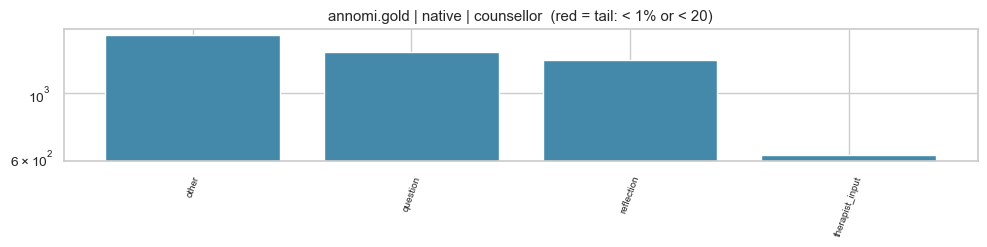

counsellor tail codes: []


,reflection_subtype,question_subtype,therapist_input_subtype
advice,0,0,145
closed,0,702,0
complex,695,0,0
information,0,0,455
negotiation,0,0,148
open,0,954,0
options,0,0,45
simple,849,0,0


In [22]:
label_table('annomi.gold', 'native')
display(an[an.speaker=='counsellor'][['reflection_subtype','question_subtype','therapist_input_subtype']].apply(lambda s: s.value_counts()).fillna(0).astype(int))

### 6.3 Agreement among AnnoMI's own annotators (7 ten-rater transcripts)

,Fleiss kappa
fleiss_main,0.737
fleiss_client,0.467
fleiss_reflection_subtype,0.496
fleiss_question_subtype,0.740
fleiss_therapist_input_subtype,0.512


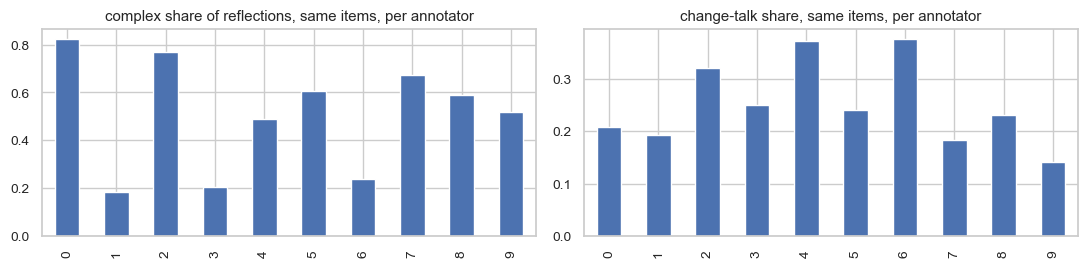

kappa vs leave-one-out majority (main behaviour): {0: 0.79, 1: 0.831, 2: 0.809, 3: 0.649, 4: 0.845, 5: 0.827, 6: 0.85, 7: 0.812, 8: 0.85, 9: 0.85}


In [23]:
ag = registry.annomi_agreement()
display(pd.Series({k: round(v, 3) for k, v in ag.items() if k.startswith('fleiss')}, name='Fleiss kappa').to_frame())
fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
pd.Series(ag['complex_share_same_items']).plot.bar(ax=ax[0], title='complex share of reflections, same items, per annotator')
pd.Series(ag['change_share_same_items']).plot.bar(ax=ax[1], title='change-talk share, same items, per annotator')
plt.tight_layout(); plt.show()
print('kappa vs leave-one-out majority (main behaviour):', ag['loo_kappa_main'])

### 6.4 Cleaning issues

In [24]:
cleaning('annomi.gold')

,check,n,share,example,severity,action
0,no casing (ASR signal),365,0.0376,,info,expected for ASR corpora
1,no punctuation (ASR signal),267,0.0275,,info,expected for ASR corpora
2,short utterances (>=3 occurrences) with conflicting T2,4,0.8000,"'yeah', 'okay', 'no'",warn,"annotation noise: report, do not relabel"
3,topic labels with stray whitespace,9,0.0677,'smoking cessation ',info,handled: stripped in eda.registry


**Takeaway (AnnoMI)**
- Counsellor main behaviour is reliable (κ 0.74). Client talk (0.47) and reflection type (0.50) are not.
- Annotator 3 is an outlier.
- Its "open/closed" convention differs from MISC (see §10.2).

## 7. `welivita.gold`: Welivita & Pu peer-support forums
2,000 written threads (1,000 CounselChat, 1,000 Reddit). Listener sentences carry 15 MITI-derived codes from two crowd workers plus expert judges.

### 7.1 Profile

In [25]:
w = F['welivita.gold']; display(profile('welivita.gold'))
print('source:', w.groupby('conv_id').source.first().value_counts().to_dict())

,value
conversations,2000
rows (units),20462
counsellor rows,17261
client rows,3201
units / conv (median),9.0
units / conv (min-max),2-48
turns / conv (median),2.5
words / unit (median),16.0
words / unit (p95),65.0
coded rows,16811


source: {'RED': 1000, 'counsel_chat': 1000}


### 7.2 Labels

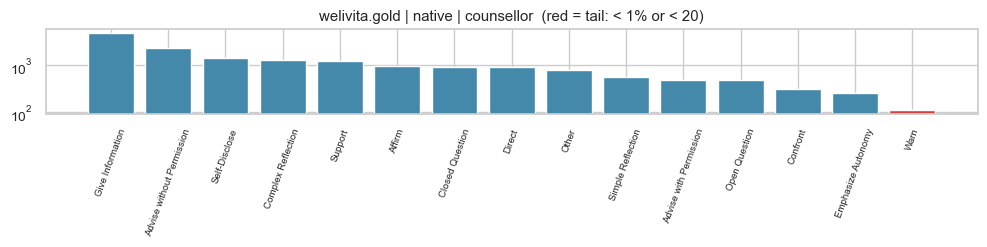

counsellor tail codes: ['Warn']


In [26]:
label_table('welivita.gold', 'native')

### 7.3 Agreement between the two crowd workers

In [27]:
display(pd.Series(registry.welivita_agreement(), name='value').to_frame())
lis = w[w.speaker == 'counsellor']
pd.crosstab(lis.native, lis.stage1_agreed, margins=True).sort_values('All', ascending=False)

,value
n,17261.000000
raw_agreement,0.414344
kappa,0.340365
stage1_agreed,7152.000000


stage1_agreed,False,True,All
native,,,
All,9659,7152,16811
Give Information,2507,2349,4856
Advise without Permission,1460,825,2285
Self-Disclose,506,884,1390
Complex Reflection,1033,261,1294
Support,665,568,1233
Affirm,603,342,945
Closed Question,258,647,905
Direct,646,252,898


### 7.4 Duplicate threads inside Welivita

In [28]:
wd = CL[(CL.dataset_a == 'welivita.gold') & (CL.dataset_b == 'welivita.gold')]
display(wd.kind.value_counts().to_frame('pairs'))
display(cleaning('welivita.gold'))

,pairs
kind,
"same opening post, different reply",316
duplicate session,30
partial overlap,10


,check,n,share,example,severity,action
0,consecutive identical utterances (same speaker),5,0.0002,['Maybe not.'],info,inspect
1,no casing (ASR signal),769,0.0376,,info,expected for ASR corpora
2,no punctuation (ASR signal),420,0.0205,,info,expected for ASR corpora
3,uncoded counsellor rows,450,0.0261,,info,expected (context rows / scheme does not code this speaker)
4,uncoded client rows,3201,1.0000,,info,expected (context rows / scheme does not code this speaker)
5,short utterances (>=3 occurrences) with conflicting T2,19,0.5000,"'good luck', 'yes', 'be well'",warn,"annotation noise: report, do not relabel"
6,duplicate dialogues (containment >= 0.9),9,0.0045,counsel_chat | 100=counsel_chat | 1857; counsel_chat | 1856=counsel_chat | 99,warn,split by duplicate cluster; dedupe in derived copy
7,listener rows with '-' / no final label,450,0.0261,,info,expected: uncodable segments


**Takeaway (Welivita)**
- The labels are weak (κ 0.34); only 7,152 of 17,261 listener sentences have crowd agreement.
- Most overlapping threads share the same question but have different answers.

## 8. `miti.casaa.gold`: CASAA MITI 4 coded training transcripts
20 transcripts coded by the MITI developers' lab. Counsellor only. Aggregates only: the transcripts are third-party material.

### 8.1 Profile

In [29]:
c = F['miti.casaa.gold']; display(profile('miti.casaa.gold', text=False))
print('alignment of coded counsellor rows:', c[c.speaker=='counsellor']['align'].value_counts().to_dict())

,value
conversations,20
rows (units),1346
counsellor rows,687
client rows,659
units / conv (median),76.0
units / conv (min-max),20-126
turns / conv (median),72.5
words / unit (median),17.0
words / unit (p95),81.0
coded rows,682


alignment of coded counsellor rows: {'turn': 598, 'multi': 50, 'sentence': 32}


### 8.2 Labels (MITI codes; `|` = multi-code turn)

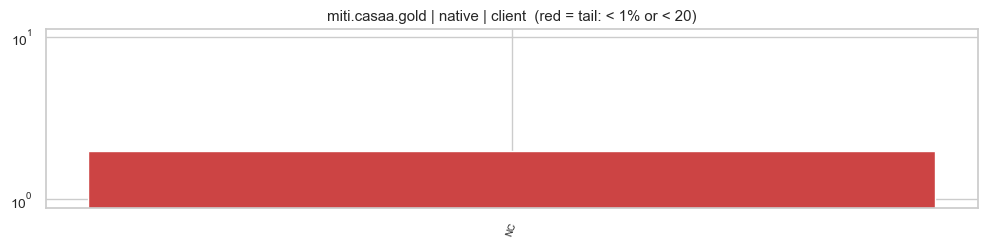

client tail codes: ['NC']


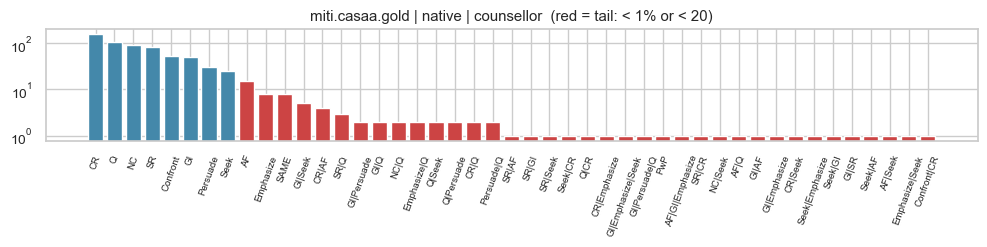

counsellor tail codes: ['AF', 'Emphasize', 'SAME', 'GI|Seek', 'CR|AF', 'SR|Q', 'GI|Persuade', 'GI|Q', 'NC|Q', 'Emphasize|Q', 'Q|Seek', 'Q|Persuade', 'CR|Q', 'Persuade|Q', 'SR|AF', 'SR|GI', 'SR|Seek', 'Seek|CR', 'Q|CR', 'CR|Emphasize', 'GI|Emphasize|Seek', 'GI|Persuade|Q', 'PwP', 'AF|GI|Emphasize', 'SR|CR', 'NC|Seek', 'AF|Q', 'GI|AF', 'GI|Emphasize', 'CR|Seek', 'Seek|Emphasize', 'Seek|GI', 'GI|SR', 'Seek|AF', 'AF|Seek', 'Emphasize|Seek', 'Confront|CR']


In [30]:
label_table('miti.casaa.gold', 'native')

### 8.3 MITI global ratings

In [31]:
pd.read_csv('data/external/casaa/casaa_globals.csv').set_index('conv_id')

,CCT,SST,PAR,EMP
conv_id,,,,
casaa_i-guess-i-dont-have-a-choice,1,4,1,1
casaa_maybe-hell-take-my-kids,2,2,2,2
casaa_should-i-really-be-honest,3,2,5,5
casaa_the-confirmed-smoker,4,4,5,5
casaa_session1miti,2,2,2,3
casaa_session2miti,2,1,1,2
casaa_session3miti,3,3,3,4
casaa_session4miti,4,3,3,3
casaa_session5miti,1,1,1,1


### 8.4 Cleaning issues

In [32]:
cleaning('miti.casaa.gold')

,check,n,share,example,severity,action
0,no casing (ASR signal),2,0.0015,,info,expected for ASR corpora
1,no punctuation (ASR signal),88,0.0654,,info,expected for ASR corpora
2,uncoded counsellor rows,7,0.0102,,info,expected (context rows / scheme does not code this speaker)
3,uncoded client rows,657,0.9970,,info,expected (context rows / scheme does not code this speaker)
4,multi-code turns left without gold (align=multi),50,0.0728,,info,handled: no gold assigned
5,SAME continuation rows,8,0.0116,,info,handled: no gold assigned
6,client rows carrying a code (source quirk),2,0.0030,,info,handled: client rows never get gold


## 9. Unlabelled pools (one subsection each)

### 9.1 `pool.hlqc`: all 257 HLQC sessions

In [33]:
display(profile('pool.hlqc'))
print('session quality label:', pd.Series([c[:4] for c in F['pool.hlqc'].conv_id.unique()]).value_counts().to_dict())
hd = CL[(CL.dataset_a == 'pool.hlqc') & (CL.dataset_b == 'pool.hlqc')]
print('duplicate session pairs inside the pool:', len(hd)); display(hd.head(10)[['conv_a','conv_b','containment']])
display(cleaning('pool.hlqc'))

,value
conversations,257
rows (units),30610
counsellor rows,15898
client rows,14712
units / conv (median),97.0
units / conv (min-max),5-540
turns / conv (median),30.0
words / unit (median),8.0
words / unit (p95),23.0
coded rows,0


session quality label: {'high': 154, 'low_': 103}
duplicate session pairs inside the pool: 53


,conv_a,conv_b,containment
0,low_003,low_005,1.000
1,low_008,low_048,1.000
6,high_011,high_014,0.983
7,low_028,low_081,0.979
10,high_016,high_085,0.978
14,high_059,high_068,0.969
15,low_024,low_083,0.968
17,high_013,high_095,0.962
18,high_036,high_138,0.960
19,high_070,high_078,0.956


,check,n,share,example,severity,action
0,consecutive identical utterances (same speaker),76,0.0025,['thank you'],info,inspect
1,no casing (ASR signal),17829,0.5825,,info,expected for ASR corpora
2,no punctuation (ASR signal),27464,0.8972,,info,expected for ASR corpora
3,near-duplicate sessions inside the pool (containment >= 0.5),51,0.1984,low_003=low_005; low_008=low_048; high_011=high_014,warn,dedupe pool in derived copy (keep one per cluster)
4,duplicate sessions with CONFLICTING high/low quality label,4,0.0784,high_025=low_086; high_084=low_026; high_036=low_051,warn,decide (session-quality label unreliable for these)
5,copies of HLQC GOLD (train) sessions under another pool id,6,0.6000,low_026=high_084; low_001=low_027; low_001=low_040; low_080=low_019; low_031=low_054; low_080=low_098,warn,exclude from pool when the pool is used for evaluation


### 9.2 `pool.miv63a`: all 173 MIBot v6.3A sessions (contains the 10 test sessions)

In [34]:
display(profile('pool.miv63a'))
o = registry.miv_outcomes('A')
display(o[['pre_importance','post_importance','pre_confidence','post_confidence','pre_readiness','post_readiness']].describe().T[['count','mean','std']].round(2))
display(cleaning('pool.miv63a'))

,value
conversations,173
rows (units),13692
counsellor rows,9835
client rows,3857
units / conv (median),76.0
units / conv (min-max),36-163
turns / conv (median),30.0
words / unit (median),12.0
words / unit (p95),25.0
coded rows,0


,count,mean,std
pre_importance,173.0,6.20,2.48
post_importance,173.0,6.92,2.64
pre_confidence,173.0,4.27,2.66
post_confidence,173.0,5.62,2.69
pre_readiness,173.0,5.86,2.67
post_readiness,173.0,6.54,2.64


,check,n,share,example,severity,action
0,empty / whitespace text,2,0.0001,,warn,drop in derived copy
1,no casing (ASR signal),1531,0.1118,,info,expected for ASR corpora
2,no punctuation (ASR signal),2243,0.1638,,info,expected for ASR corpora


### 9.3 `pool.miv63b`: MIBot v6.3B run (165 sessions)

In [35]:
display(profile('pool.miv63b')); display(cleaning('pool.miv63b'))

,value
conversations,165
rows (units),11771
counsellor rows,6844
client rows,4927
units / conv (median),69.0
units / conv (min-max),22-164
turns / conv (median),40.0
words / unit (median),12.0
words / unit (p95),26.0
coded rows,0


,check,n,share,example,severity,action
0,consecutive identical utterances (same speaker),1,0.0001,['yes'],info,inspect
1,no casing (ASR signal),3219,0.2735,,info,expected for ASR corpora
2,no punctuation (ASR signal),2856,0.2426,,info,expected for ASR corpora


## 10. Comparisons
Every table here compares datasets on purpose. Its title names what is compared.

### 10.1 Overlaps: which sessions appear in more than one dataset?
5-gram containment between conversations, ignoring phrases found in more than 5 conversations. A score ≥ 0.10 is a real link; unrelated
sessions score ≤ 0.02. Two kinds:
- **duplicate session:** the same session under two ids;
- **same opening post, different reply:** Welivita only.

In [36]:
CL.groupby(['dataset_a', 'dataset_b', 'kind']).agg(pairs=('containment', 'size'), max_containment=('containment', 'max')).reset_index()

,dataset_a,dataset_b,kind,pairs,max_containment
0,annomi.gold,misc.hlqc.gold,duplicate session,4,0.692
1,annomi.gold,pool.hlqc,duplicate session,68,0.851
2,misc.hlqc.gold,miti.casaa.gold,duplicate session,1,0.397
3,misc.hlqc.gold,pool.hlqc,duplicate session,6,0.949
4,miti.casaa.gold,pool.hlqc,duplicate session,2,0.397
5,pool.hlqc,pool.hlqc,duplicate session,53,1.000
6,welivita.gold,welivita.gold,duplicate session,30,1.000
7,welivita.gold,welivita.gold,partial overlap,10,0.921
8,welivita.gold,welivita.gold,"same opening post, different reply",316,0.720


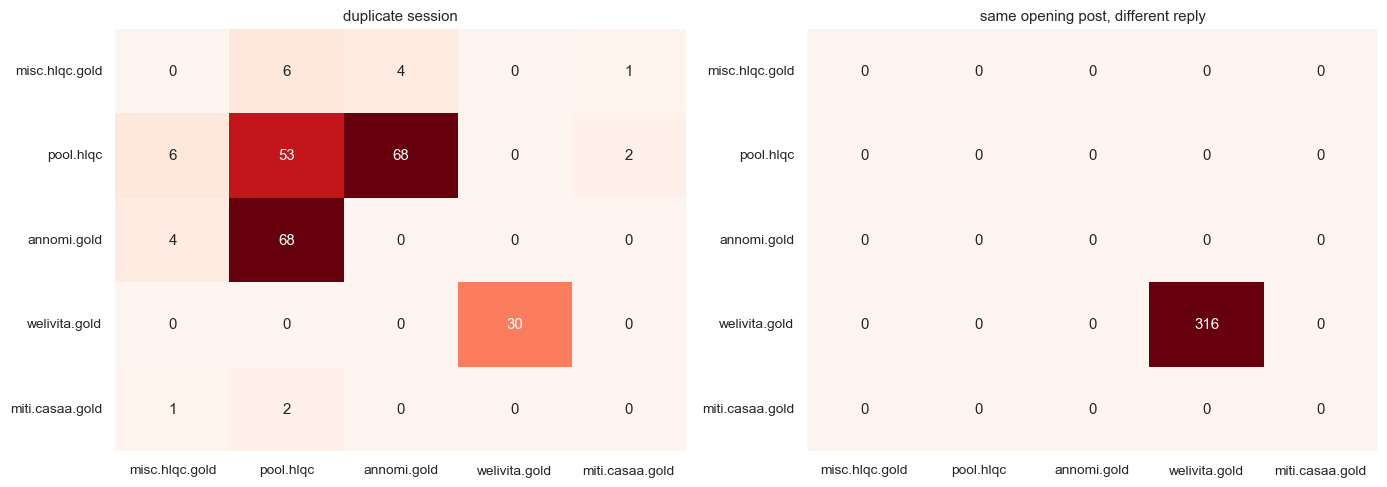

In [37]:
ids = [k for k in F if k in set(CL.dataset_a) | set(CL.dataset_b)]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, kind in enumerate(['duplicate session', 'same opening post, different reply']):
    M = pd.DataFrame(0, index=ids, columns=ids)
    for a, b in zip(CL[CL.kind == kind].dataset_a, CL[CL.kind == kind].dataset_b):
        M.loc[a, b] += 1
        if a != b: M.loc[b, a] += 1
    sns.heatmap(M, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax[i]); ax[i].set_title(kind)
plt.tight_layout(); plt.show()

In [38]:
def pairs_of(a, b):
    x = CL[((CL.dataset_a == a) & (CL.dataset_b == b)) | ((CL.dataset_a == b) & (CL.dataset_b == a))]
    return x[['dataset_a','conv_a','dataset_b','conv_b','containment']].reset_index(drop=True)
for other in ['annomi.gold', 'miti.casaa.gold', 'pool.hlqc']:
    t = pairs_of('misc.hlqc.gold', other); print(f'HLQC TRAIN sessions also in {other}:'); display(t[t.conv_a != t.conv_b])
print('MIV6.3A TEST sessions that appear elsewhere:', len(CL[(CL.dataset_a == 'misc.miv63a.gold') | (CL.dataset_b == 'misc.miv63a.gold')]))
display(overlap.known_relations(F))

HLQC TRAIN sessions also in annomi.gold:


,dataset_a,conv_a,dataset_b,conv_b,containment
0,annomi.gold,53,misc.hlqc.gold,low_001,0.692
1,annomi.gold,15,misc.hlqc.gold,low_080,0.668
2,annomi.gold,21,misc.hlqc.gold,high_099,0.663
3,annomi.gold,44,misc.hlqc.gold,low_033,0.618


HLQC TRAIN sessions also in miti.casaa.gold:


,dataset_a,conv_a,dataset_b,conv_b,containment
0,misc.hlqc.gold,high_121,miti.casaa.gold,casaa_emmys-first-encounter,0.397


HLQC TRAIN sessions also in pool.hlqc:


,dataset_a,conv_a,dataset_b,conv_b,containment
0,misc.hlqc.gold,low_026,pool.hlqc,high_084,0.949
1,misc.hlqc.gold,low_001,pool.hlqc,low_027,0.930
2,misc.hlqc.gold,low_001,pool.hlqc,low_040,0.901
3,misc.hlqc.gold,low_080,pool.hlqc,low_019,0.874
4,misc.hlqc.gold,low_031,pool.hlqc,low_054,0.821
5,misc.hlqc.gold,low_080,pool.hlqc,low_098,0.595


MIV6.3A TEST sessions that appear elsewhere: 0


,dataset_a,dataset_b,relation,detail,verified
0,misc.hlqc.gold,pool.hlqc,subset,the 10 gold sessions are pool sessions (same conv_id),10/10 misc.hlqc.gold sessions found in pool.hlqc
1,misc.miv63a.gold,pool.miv63a,subset,the 10 test sessions are pool sessions (same conv_id),10/10 misc.miv63a.gold sessions found in pool.miv63a
2,annomi.gold,annomi.gold,derived,AnnoMI-full -> AnnoMI-simple -> data/AnnoMI.csv (AutoMISC MISC map) -> data/manual/AnnoMI_eval.csv; parsed...,
3,welivita.gold,welivita.gold,derived,release MI_Dataset.csv -> external/welivita_mi_parsed.csv -> manual/Welivita_eval.csv; selftrain pseudo-la...,


**Why the duplicate counts differ:**
- **HLQC pool:** scraped from video sites, so the same demo was often uploaded more than once.
- **Welivita:** one question, several therapists' answers.
- **AnnoMI and CASAA:** curated distinct videos.
- **MIV:** one participant per session.

### 10.2 Same sessions, different coders: HLQC labels vs AnnoMI experts and the CASAA MITI reference
Four HLQC train sessions are also AnnoMI transcripts, and HLQC `high_121` is CASAA's *Emmy*. Utterances are aligned word by word and
compared per reference turn, because AnnoMI and CASAA code whole turns. Compare κ with the reference group's own reliability: AnnoMI
raters reach 0.74 (counsellor) and 0.47 (client) among themselves.

In [39]:
X = quality.cross_annotation()
print('Transcription: HLQC ASR text vs the manual transcript of the same session')
display(X['wer'].rename(columns={'words_hyp': 'HLQC words', 'words_ref': 'reference words'}))
rows = []
for k, label in [('annomi_counsellor', 'HLQC vs AnnoMI: counsellor main behaviour (per turn)'),
                 ('annomi_client', 'HLQC vs AnnoMI: client talk type (per turn)'),
                 ('annomi_open_closed', 'HLQC OQ/CQ vs AnnoMI open/closed'),
                 ('annomi_simple_complex', 'HLQC SR/CR vs AnnoMI simple/complex'),
                 ('casaa_counsellor', 'HLQC vs CASAA MITI reference (per turn)')]:
    v = X[k]; rows.append({'comparison': label, 'n': v['n'], 'agreement': v.get('agreement'), 'kappa': v.get('kappa')})
display(pd.DataFrame(rows))
for k, t in [('annomi_client', 'HLQC (rows) vs AnnoMI (columns): client talk'),
             ('annomi_open_closed', 'HLQC (rows) vs AnnoMI (columns): open/closed'),
             ('casaa_counsellor', 'HLQC (rows, mapped to MITI) vs CASAA (columns)')]:
    print(t); display(X[k]['confusion'])

Transcription: HLQC ASR text vs the manual transcript of the same session


,hlqc,reference,HLQC words,reference words,matched,WER
0,low_001,AnnoMI 53,1786,1849,1707,0.088
1,low_080,AnnoMI 15,581,601,546,0.106
2,high_099,AnnoMI 21,2516,2802,2346,0.172
3,low_033,AnnoMI 44,1771,2013,1656,0.188
4,high_121,CASAA Emmy,3662,3436,2976,0.253


,comparison,n,agreement,kappa
0,HLQC vs AnnoMI: counsellor main behaviour (per turn),194,0.722,0.584
1,HLQC vs AnnoMI: client talk type (per turn),185,0.746,0.364
2,HLQC OQ/CQ vs AnnoMI open/closed,114,0.395,0.067
3,HLQC SR/CR vs AnnoMI simple/complex,21,0.810,0.538
4,HLQC vs CASAA MITI reference (per turn),34,0.441,0.319


HLQC (rows) vs AnnoMI (columns): client talk


independent coder,change,neutral,sustain
HLQC gold,,,
change,18,3,1
neutral,28,118,12
sustain,1,2,2


HLQC (rows) vs AnnoMI (columns): open/closed


independent coder,closed,open
HLQC gold,,
closed,10,68
open,1,35


HLQC (rows, mapped to MITI) vs CASAA (columns)


independent coder,AF,CR,Emphasize,GI,Persuade,Q,Seek
HLQC gold,,,,,,,
AF,0,0,0,1,0,0,0
CR,1,7,0,0,0,1,0
Emphasize,0,0,2,0,0,0,0
GI,0,0,0,1,1,0,0
NC,0,0,1,1,0,0,1
PwP,0,0,0,0,0,0,1
Q,0,1,0,0,0,5,1
SR,0,9,0,0,0,0,0


In [40]:
am = X['annomi_pairs']; cc = am[am.speaker == 'counsellor']
ex = cc[(cc.hlqc_t2 == 'CQ') & (cc.annomi_sub == 'open')]
print('HLQC CQ but AnnoMI "open" (MISC rule: yes/no or specific-fact questions are CQ):')
for t in ex.hlqc_text.drop_duplicates().head(8): print('  -', t[:110])
print('AnnoMI annotator behind these rows:', ex.annomi_annotator.value_counts().to_dict())

HLQC CQ but AnnoMI "open" (MISC rule: yes/no or specific-fact questions are CQ):
  - are you doing school
  - what kind of grades do you get
  - and do you know where you're going to apply to college
  - so do you drink alcohol
  - and how often do you think you drink
  - what do you think's the most you've ever had
  - all right have you ever done that
  - have you ever done
AnnoMI annotator behind these rows: {3: 44, 4: 22, 6: 2}


**Takeaway.**
- **Counsellor behaviour:** HLQC and AnnoMI agree at κ 0.58.
- **Client talk:** HLQC labels neutral much of what AnnoMI calls change talk (κ 0.36).
- **Open/closed:** HLQC follows the MISC rule, while AnnoMI's "open" is broader.
- **Reflections:** against the MITI reference, HLQC's simple reflections are often complex.

### 10.3 Train (`misc.hlqc.gold`) vs test (`misc.miv63a.gold`)

Label share, train vs test (one row per code):


,speaker,code,train n,test n,train %,test %,ratio train/test,only in
0,counsellor,FI,198,56,19.0,9.7,1.97,
1,counsellor,SR,137,134,13.2,23.1,0.57,
2,counsellor,CQ,132,75,12.7,12.9,0.98,
3,counsellor,OQ,90,79,8.7,13.6,0.64,
4,counsellor,CR,85,42,8.2,7.2,1.13,
5,counsellor,ADP,81,42,7.8,7.2,1.08,
6,counsellor,ST,76,13,7.3,2.2,3.26,
7,counsellor,FA,55,4,5.3,0.7,7.67,
8,counsellor,ADW,31,0,3.0,0.0,inf,train
9,counsellor,RCW,25,0,2.4,0.0,inf,train


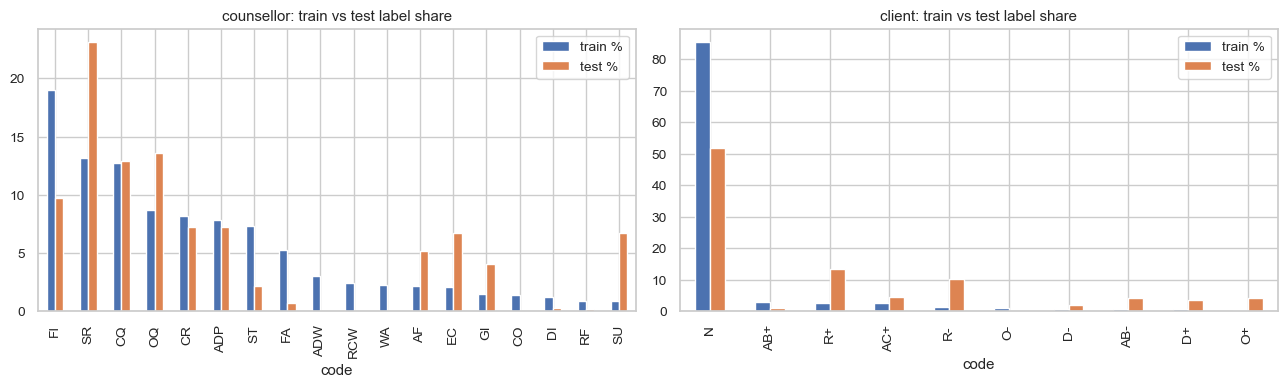

Training labels on codes the test never has: {'client': 13, 'counsellor': 95}
Same utterance text in both sets, with each set's labels:


,speaker,k,train labels,test labels,n,same majority
0,client,no,{'N': 4},{'N': 14},18,True
1,client,okay,{'N': 14},{'N': 1},15,True
2,client,yes,{'N': 4},{'N': 6},10,True
3,client,thanks,{'N': 5},{'N': 2},7,True
4,counsellor,all right,"{'FI': 4, 'FA': 1}",{'FA': 1},6,False
5,counsellor,how are you doing today,"{'FI': 1, 'OQ': 1}",{'OQ': 4},6,False
6,counsellor,great,{'FI': 1},"{'FI': 3, 'FA': 1}",5,True
7,client,ok,{'N': 1},{'N': 3},4,True


In [41]:
sh = quality.shift()
print('Label share, train vs test (one row per code):'); display(sh)
top = sh[sh['test n'] + sh['train n'] >= 10]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for i, spk in enumerate(['counsellor', 'client']):
    top[top.speaker == spk].set_index('code')[['train %', 'test %']].plot.bar(ax=ax[i], title=f'{spk}: train vs test label share')
plt.tight_layout(); plt.show()
print('Training labels on codes the test never has:', sh[sh['only in'] == 'train'].groupby('speaker')['train n'].sum().to_dict())
print('Same utterance text in both sets, with each set\'s labels:'); display(quality.train_test_convention())

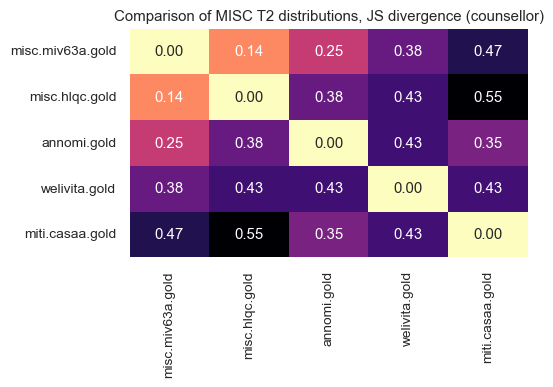

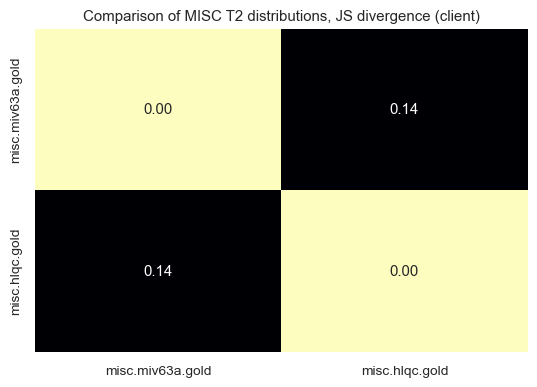

In [42]:
for spk in ['counsellor', 'client']:
    J = stats.js_matrix({k: F[k] for k in ['misc.miv63a.gold', 'misc.hlqc.gold', 'annomi.gold', 'welivita.gold', 'miti.casaa.gold']}, spk, 't2')
    if len(J) > 1:
        plt.figure(figsize=(5.5, 4)); sns.heatmap(J, annot=True, fmt='.2f', cmap='magma_r', cbar=False)
        plt.title(f'Comparison of MISC T2 distributions, JS divergence ({spk})'); plt.tight_layout(); plt.show()

### 10.4 Impact on the main model (`ft1mix_bare` trained on HLQC, tested on MIV6.3A, 3 seeds)

In [43]:
I = quality.impact()
display(I['summary']); display(I['recall_by_code'])
for k in ['gold_FI_predicted_as', 'gold_change_sustain_predicted_as', 'predictions_of_train_only_codes']:
    print(k); display(I[k])

,value
test utterances x seeds,2463.000
gold FI pleasantries predicted FI,0.947
gold client change/sustain predicted N,0.316
gold SU recall,0.385
gold EC recall,0.325
predictions of train-only codes (per seed),7.300


,speaker,t2_label_GT,n_per_seed,recall
24,counsellor,SR,134,0.423
22,counsellor,OQ,79,0.958
15,counsellor,CQ,75,0.840
20,counsellor,FI,56,0.905
13,counsellor,ADP,42,0.746
16,counsellor,CR,42,0.857
18,counsellor,EC,39,0.325
26,counsellor,SU,39,0.385
14,counsellor,AF,30,0.600
21,counsellor,GI,24,0.542


gold_FI_predicted_as


pred,AF,CR,EC,FI,SU
kind,,,,,
other FI,0.00,0.11,0.06,0.81,0.02
pleasantry,0.02,0.00,0.00,0.95,0.04


gold_change_sustain_predicted_as


,share of gold change/sustain-talk predictions
pred,
N,0.316
R+,0.181
R-,0.141
AC+,0.101
D+,0.086
D-,0.043
AB-,0.040
AB+,0.034
C+,0.014


predictions_of_train_only_codes


,pred,t2_label_GT,count over 3 seeds
0,C-,AB-,2
1,O-,AB-,2
2,O-,N,2
3,RCW,ADP,3
4,RCW,GI,8
5,WA,GI,5


**Summary of the quality issues and their effect on the test**

| Issue (source) | Effect on the MIV test | Possible action (not applied) |
|---|---|---|
| HLQC FI catch-all (§4.3–4.5) | small: test pleasantries still predicted FI 95% | relabel standalone acknowledgements FI→FA in a derived copy; read HLQC-CV numbers with care |
| HLQC under-codes change talk (§10.2) | **large**: 32% of change/sustain predicted neutral; O+ recall 0.03 | re-annotate or reweight HLQC client labels |
| SR/CR line differs between coder groups (§4.6, §5.6, §10.2) | **largest**: 51% of test SR predicted CR | agree an SR/CR guideline; also report reflections at T1 |
| SU / EC / permission-seeking missing from HLQC (§4.2, §10.3) | SU 0.39, EC 0.33 recall | targeted examples |
| Train-only IMI codes (§10.3) | ~7 spurious predictions per run | downweight, or train them at T1 only |
| AnnoMI "open" ≠ MISC OQ (§10.2) | AnnoMI transfer test only | score AnnoMI questions at T1 |

## 11. Splits (`data/splits/*.json`, built by `python -m eda.splits`)
The splits were reviewed rather than inherited: see `docs/experiments/2026-10-05-split-review.md`. §11.0 re-runs the evidence, and each
later subsection is one manifest.

### 11.0 Why these splits: evidence (`eda.split_eval`)
A transparent CPU proxy (TF-IDF + logistic regression, one classifier per speaker) trained under each candidate protocol. It measures data and
convention match, not 7B model capacity. Every MIV score covers all 821 utterances.

In [44]:
from eda import split_eval
print('Candidate protocols (MIV6.3A gold; P1 scores HLQC):'); display(split_eval.protocols())
print('External check on CASAA (counsellor; clean sessions):'); display(split_eval.external_casaa())
print('Template leakage across MIV folds:', split_eval.template_leak())
print('Power of the MIV test (main model, session-cluster bootstrap):'); display(split_eval.test_power())
rep = split_eval.test_representativeness()
print('Representativeness of the 10 test sessions within the MI target population:'); display(rep); print(rep.attrs)

Candidate protocols (MIV6.3A gold; P1 scores HLQC):


,counsellor macro-F1,counsellor acc,client macro-F1,client acc
P0 train HLQC -> test MIV (current),0.260,0.462,0.083,0.502
"P2 MIV 5-fold CV, MIV only",0.474,0.647,0.192,0.577
P3 HLQC + other MIV folds -> MIV fold,0.442,0.612,0.209,0.552
P1 train MIV -> test HLQC (reversed),0.127,0.284,0.109,0.673


External check on CASAA (counsellor; clean sessions):


,CASAA T2 macro-F1 (6 exact codes),CASAA T2 acc,CASAA T1 acc
train HLQC,0.178,0.219,0.457
train MIV,0.144,0.170,0.413
train HLQC + MIV,0.234,0.235,0.492


Template leakage across MIV folds: {'long utterances': 652, 'repeated in another fold': 14}
Power of the MIV test (main model, session-cluster bootstrap):


,macro-F1,95% CI,drop-one-session range,codes,codes with < 5 test examples
speaker,,,,,
counsellor,0.501,"[0.435, 0.602]",0.462-0.538,14,"FA, DI, RF"
client,0.414,"[0.322, 0.522]",0.368-0.474,13,"AB+, TS+, N-, AC-"


Representativeness of the 10 test sessions within the MI target population:


,test (10),rest of target population,Mann-Whitney p
measure,,,
utterances,82.1,80.62,0.800
delta_confidence,1.9,1.71,0.722
delta_readiness,0.1,0.79,0.153


{'status of test sessions': {'low-confidence-or-discordant': 10}}


**Takeaway.**
- MIV6.3A keeps the test role, because it has the most reliable labels and comes from the target population.
- HLQC is never a test set.
- In-domain MIV data beats the larger HLQC set for training.
- Pooled HLQC + MIV generalises best to CASAA.

So **pooled training with MIV cross-validation (`misc_pooled_cv`) is proposed as the primary protocol**, with `misc_main` kept as the cold-start
transfer setting.

### 11.0b Leakage checks
- MISC pooled CV: participants, near-duplicate text across folds, and codes present in only one fold.
- AnnoMI: splitting by transcript vs by video series vs by unseen annotator.
- Welivita: shared opening posts and source shift.

In [45]:
display(pd.Series(split_eval.pooled_cv_leakage(), name='value').to_frame())
print('AnnoMI scheme, proxy CV under three groupings:'); display(split_eval.annomi_grouping())
print('Welivita scheme, proxy CV (agreed labels):'); display(split_eval.welivita_grouping())

,value
distinct participants in the 10 sessions,10
duplicate participant ids among 173,0
counsellor utterances (>=6 words) with a >=0.9-similar one in another fold,18 of 532
codes present in only one fold,"[AC-, RF]"
test utterances per fold,"{0: 193, 1: 126, 2: 187, 3: 169, 4: 146}"


AnnoMI scheme, proxy CV under three groupings:


,counsellor macro-F1,counsellor acc,client macro-F1,client acc
by transcript (old split),0.715,0.748,0.488,0.616
by video series (new split),0.718,0.751,0.495,0.619
by unseen annotator + series,0.704,0.740,0.472,0.605


Welivita scheme, proxy CV (agreed labels):


,macro-F1,acc
by dialogue (same post may cross),0.475,0.720
by same-post cluster (split used),0.469,0.714
train counsel_chat -> test RED,0.376,0.541
train RED -> test counsel_chat,0.363,0.622


**Takeaway.**
- **Pooled CV:** no session or person crosses folds, and text overlap is limited to a few chatbot templates.
- **Old AnnoMI split:** it spread 13 video series across splits. The proxy shows no measurable inflation, but the split is now series-level.
- **Welivita:** source shift is the big effect, so the split stratifies by source and cross-source is a robustness check.

### 11.0c Lucky draws: how much does one split, fold assignment or seed move the score?
- Pooled CV under 20 random 5-fold assignments vs leave-one-session-out (LOSO, no randomness).
- A single random AnnoMI test split, drawn 20 times.

The 7B training-seed spread is already measured in `EXPANSION_RESULTS.md` (up to ±0.033 macro-F1 over 3 seeds).

In [46]:
print('Fold-assignment draws (20) and LOSO, macro-F1:'); display(split_eval.fold_draw_variance())
print('Single 15% AnnoMI test split, 20 draws:'); display(split_eval.single_split_variance())

Fold-assignment draws (20) and LOSO, macro-F1:


,pooled counsellor,pooled client,MIV-only counsellor,MIV-only client,diff counsellor,diff client
mean,0.440,0.219,0.468,0.194,-0.028,0.025
std,0.010,0.011,0.013,0.013,0.012,0.013
min,0.407,0.193,0.444,0.165,-0.056,0.001
max,0.458,0.236,0.493,0.222,-0.012,0.045
LOSO (no draw),0.445,0.223,0.483,0.206,-0.038,0.017


Single 15% AnnoMI test split, 20 draws:


,counsellor macro-F1,counsellor acc,client macro-F1,client acc
mean,0.722,0.757,0.493,0.618
std,0.022,0.021,0.031,0.036
min,0.689,0.715,0.458,0.544
max,0.779,0.792,0.581,0.662


**Takeaway.**
- **Fold assignment** moves macro-F1 by SD ≈ 0.01, but a single draw can show a pooled-vs-MIV-only client gain anywhere from +0.00 to +0.05. So pooled CV uses LOSO for headline numbers, and re-draws the folds with each training seed otherwise.
- **A single AnnoMI split** moves it by SD 0.02–0.03, with a range of about 0.1. So AnnoMI and Welivita use grouped 5-fold CV, not one split.
- **Every claimed difference** needs ≥ 3 matched seeds and session-bootstrap intervals (`variance_rules` in every manifest).

### 11.0d Exemplars: where do the few-shot exemplars come from?
All three exemplar channels draw from HLQC gold: few-shot prompts, the retrieval index and the synthesis style anchors.
- **MIV:** fine.
- **AnnoMI and CASAA:** some of those HLQC sessions *are* test transcripts, so the AnnoMI/CASAA exclusions apply to any model that saw HLQC by any route.

In [47]:
ex = split_eval.exemplar_sources(); ex1 = ex[ex.file == 'exemplars.json']
print(f"{(ex1['duplicated in test corpus'] != '').sum()} of {len(ex1)} few-shot exemplars come from HLQC sessions duplicated in a test corpus")
display(ex1.groupby(['session', 'duplicated in test corpus']).size().rename('exemplars').reset_index())
print('exemplar rules (in misc_main / misc_pooled_cv):'); display(pd.Series(MAN['misc_main']['exemplar_rules'], name='rule').to_frame())

22 of 41 few-shot exemplars come from HLQC sessions duplicated in a test corpus


,session,duplicated in test corpus,exemplars
0,high_001,,3
1,high_099,AnnoMI 21,7
2,high_117,,4
3,high_121,CASAA Emmy,5
4,high_127,,2
5,low_001,AnnoMI 53,2
6,low_026,,6
7,low_031,,4
8,low_033,AnnoMI 44,4
9,low_080,AnnoMI 15,4


exemplar rules (in misc_main / misc_pooled_cv):


,rule
cross_corpus,22 of 41 few-shot exemplars (and the retrieval index and synthesis anchors) include HLQC sessions that are...
draws,prompted arms use >= 3 exemplar draws (different selection seeds) and report mean +- sd; the exemplar draw...
same_corpus_scoring,"when scoring on the corpus the exemplars come from (HLQC CV, teacher screens), drop the exemplar SESSIONS ..."
source,"exemplars come only from the training side of the split: HLQC gold under misc_main; under pooled CV, HLQC ..."


### 11.1 MISC main setting (unchanged): train `misc.hlqc.gold`, test `misc.miv63a.gold` + CASAA

In [48]:
mm = MAN['misc_main']
print('train:', mm['train']['misc.hlqc.gold'])
print('test:', {k: len(v) for k, v in mm['test'].items()})
for k, v in mm['exclude'].items(): print('exclude', k, '->', v)

train: ['high_001', 'high_099', 'high_117', 'high_121', 'high_127', 'low_001', 'low_026', 'low_031', 'low_033', 'low_080']
test: {'misc.miv63a.gold': 10, 'miti.casaa.gold (MISC-mapped)': 18}
exclude annomi.gold (additionally, when the model saw pool.hlqc: self-training/retrieval over the pool) -> ['2', '3', '8', '9', '15', '17', '19', '21', '23', '24', '27', '32', '33', '36', '40', '44', '50', '52', '53', '59', '65', '66', '68', '69', '72', '74', '80', '82', '87', '90', '91', '92', '97', '102', '103', '106', '107', '112', '113', '114', '115', '118', '119', '123', '126', '127', '130', '131']
exclude annomi.gold (transfer test of any model that saw HLQC gold: training, exemplars, retrieval or synthetic data) -> ['15', '21', '44', '53']
exclude miti.casaa.gold -> ['casaa_emmys-first-encounter', 'casaa_rounder-miti-4']


### 11.1b PROPOSED: `misc_pooled_cv` (HLQC + MIV training sessions; LOSO for headline, seed-tied 5-fold otherwise)

In [49]:
pc = json.load(open('data/splits/misc_pooled_cv.json'))
print(pc['status']); print('recommended:', pc['recommended_design']); print('checkpoint selection:', pc['checkpoint_selection'])
lo = pc['designs']['loso']
display(pd.DataFrame({k: {'train MIV sessions': len(v['train']['misc.miv63a.gold']), 'train HLQC sessions': len(v['train']['misc.hlqc.gold']),
                          'test MIV session': ', '.join(v['test']['misc.miv63a.gold'])} for k, v in lo.items()}).T)
print('5-fold, seed-tied: one fold assignment per training seed:', list(pc['designs']['5fold_seed_tied']))

PROPOSED (pending decision); misc_main stays the reported setting until then
recommended: loso for headline numbers (10 folds, no fold-assignment randomness, 9 MIV sessions in every training set); 5fold_seed_tied for exploratory arms (training seed s uses fold draw s, so the reported spread includes fold-assignment variance)
checkpoint selection: HLQC validation fold as in misc_main (val_folds 7, val_fold 0); never an MIV session


,train MIV sessions,train HLQC sessions,test MIV session
0,9,10,59cb95053306be000195be2e
1,9,10,60dde1621f6e206dea63a7dd
2,9,10,6127b32b912465823dca1e4b
3,9,10,6481e7756969fcd48ea9c634
4,9,10,663b79f76293a4480abba57d
5,9,10,663fd7ca84b7978432d6070b
6,9,10,671fff4fced93c3e5a17f230
7,9,10,67203fd3fe9e55e9ec82fc1f
8,9,10,67336dc4beb89674ca687d87
9,9,10,6735337bd46a0b33a2bcf429


5-fold, seed-tied: one fold assignment per training seed: ['1', '2', '42']


### 11.2 `annomi.gold` own scheme: 5-fold CV grouped by video series

In [50]:
a = {c: f'fold {f}' for c, f in MAN['annomi_own']['folds'].items()}; print(MAN['annomi_own']['design']); print('transcripts per fold:', pd.Series(a).value_counts().sort_index().to_dict())
print('multi-transcript video series (kept in one split):', len(MAN['annomi_own']['series']))
display(pd.DataFrame([{'series': g, 'transcripts': ', '.join(ms), 'fold': a[ms[0]],
                       'titles': ' | '.join(F['annomi.gold'][F['annomi.gold'].conv_id.isin(ms)].groupby('conv_id').video_title.first().head(3))}
                      for g, ms in MAN['annomi_own']['series'].items()]).head(12))
df = F['annomi.gold'].assign(split=F['annomi.gold'].conv_id.map(a)); pd.crosstab([df.speaker, df.native], df.split)

5-fold CV grouped by video series, stratified by series MI quality. For test fold k, dev = fold (k+1) mod 5, train = the other folds. Every transcript is tested exactly once (no single-split lucky draw: one 15% split moved proxy macro-F1 by SD 0.022-0.031).
transcripts per fold: {'fold 0': 25, 'fold 1': 37, 'fold 2': 25, 'fold 3': 25, 'fold 4': 21}
multi-transcript video series (kept in one split): 31


,series,transcripts,fold,titles
0,1,"1, 55, 63, 99, 101",fold 1,"NEW VIDEO: Brief intervention: ""Dave"" | Brief intervention: ""Jill"" | NEW VIDEO: Brief intervention: ""Miguel"""
1,10,"10, 66",fold 0,ComMIt Diabetes Dialogue without MI | ComMIt Diabetes Dialogue with MI
2,109,"109, 123",fold 0,The Effective Dentist: Motivational Interviewing Demonstration | The Ineffective Dentist: Non-Motivational...
3,11,"11, 26",fold 4,Motivational Interviewing in Juvenile Justice Settings - 1 | Motivational Interviewing in Juvenile Justice...
4,12,"12, 38, 108",fold 4,Part Three: Motivational Interviewing in an Integrated Care Setting (Social Worker Scenario) | Part One: M...
5,128,"128, 130",fold 3,The TEACH Project - The Effective Health Practitioner | The TEACH Project - The Ineffective Health Practit...
6,15,"15, 24",fold 1,The Ineffective Pharmacist: Non-Motivational Approach | The Effective Pharmacist: Motivational Interviewin...
7,16,"16, 37, 83",fold 2,Motivational Techniques - Daryl interviews Ricky - 3 | Motivational Techniques - Daryl interviews Ricky - ...
8,18,"18, 49",fold 3,Motivational Techniques - Ken interviews Catherine - 1 | Motivational Techniques - Ken interviews Catherin...
9,20,"20, 106",fold 1,The Ineffective Physician: Non-Motivational Approach | The Effective Physician: Motivational Interviewing ...


split                       fold 0  fold 1  fold 2  fold 3  fold 4
speaker    native                                                 
client     change              200     366     213     165     230
           neutral             578     915     476     615     518
           sustain             121     141      86     107      86
counsellor other               275     427     252     325     307
           question            281     478     219     235     173
           reflection          224     382     232     186     272
           therapist_input     131     150      84     159      90

### 11.3 `welivita.gold` own scheme: 5-fold CV grouped by same-post cluster (stage-I-agreed labels)

In [51]:
s = {c: f'fold {f}' for c, f in MAN['welivita_own']['folds'].items()}; print(MAN['welivita_own']['design']); print('dialogues per fold:', pd.Series(s).value_counts().sort_index().to_dict())
df = F['welivita.gold'].assign(split=F['welivita.gold'].conv_id.map(s)); df = df[(df.speaker != 'counsellor') | df.stage1_agreed]
pd.crosstab([df.speaker, df.native], df.split)

5-fold CV grouped by same-post/duplicate cluster, stratified by source. For test fold k, dev = fold (k+1) mod 5. Every dialogue is tested exactly once.
dialogues per fold: {'fold 0': 398, 'fold 1': 404, 'fold 2': 395, 'fold 3': 405, 'fold 4': 398}


split                                 fold 0  fold 1  fold 2  fold 3  fold 4
speaker    native                                                           
counsellor Advise with Permission         13       9      13      10      12
           Advise without Permission     143     176     163     192     151
           Affirm                         67      55      62      68      90
           Closed Question               130     146     102     118     151
           Complex Reflection             40      66      58      47      50
           Confront                       16      18      13      20      11
           Direct                         41      56      50      50      55
           Emphasize Autonomy              9      10       9       5       9
           Give Information              514     507     426     429     473
           Open Question                  60     105      53      78      66
           Other                          60      59      57      67     102
           Self-Disclose                 171     169     185     176     183
           Simple Reflection              27      32      26      25      22
           Support                        96     148     106     111     107
           Warn                            0       4       3       1       0

### 11.3b MITI 4 scheme (`miti_scheme.json`)

In [52]:
ms = MAN['miti_scheme']
print('test sessions:', len(ms['test'])); display(pd.Series(ms['training_options'], name='training option').to_frame())
print('not mappable from MISC:', ms['not_mappable'])

test sessions: 18


,training option
A (recommended),MISC-trained model + MISC->MITI mapping (no MITI training data needed)
B,"welivita.gold (MITI-derived, written forum; all folds) -> CASAA: cross-domain, weak labels"
C (if obtained),"MI-TAGS (MITI 4.2, 242 sessions) after dedup against HLQC, AnnoMI and CASAA"


not mappable from MISC: ['Seek (MISC folds permission-seeking into EC)', 'Q open/closed is not split in MITI']


### 11.4 Pools (exclusion lists)

In [53]:
for p, v in MAN['pools'].items():
    if isinstance(v, dict):
        print(f'=== {p}'); display(pd.Series({k: (len(x) if isinstance(x, list) else x) for k, x in v.items()}, name='value').to_frame())

=== pool.hlqc


,value
exclude_always,0
exclude_if_annomi_is_test,63
exclude_if_casaa_is_test,2
gold_sessions_and_their_copies,16
notes,"Training-side pool, so gold copies are not a test leak; drop `redundant_duplicates` to avoid double-weight..."
redundant_duplicates,45


=== pool.miv63a


,value
exclude_always,10
notes,Contains the 10 MIV6.3A test sessions. selftrain.label_pool already drops them plus near-duplicate templat...


=== pool.miv63b


,value
exclude_always,0
notes,No session-level overlap with the test set; 22/652 long test utterances recur verbatim (templated chatbot ...


## 12. Checks (fail loudly if a number quoted in the docs drifts)

In [54]:
assert len(F['misc.miv63a.gold']) == 821 and len(F['misc.hlqc.gold']) == 1925
assert len(F['annomi.gold']) == 9699 and len(F['welivita.gold']) == 20462 and len(F['miti.casaa.gold']) == 1346
assert abs(ag['fleiss_main'] - 0.737) < 1e-3 and abs(registry.welivita_agreement()['kappa'] - 0.340) < 1e-3
r = A.set_index(['dataset', 'rule'])
assert r.loc[('misc.hlqc.gold', "standalone acknowledgement ('okay', 'yeah', 'mm-hmm', 'right' ...)"), 'flagged %'] == 63.6
assert r.loc[('misc.hlqc.gold', 'share of counsellor utterances coded FI'), 'flagged %'] == 19.0
assert X['annomi_client']['kappa'] == 0.364 and X['annomi_counsellor']['kappa'] == 0.584
assert float(I['summary'].loc['gold client change/sustain predicted N', 'value']) == 0.316
pairs = set(zip(CL.conv_a, CL.conv_b)) | set(zip(CL.conv_b, CL.conv_a))
assert ('high_121', 'casaa_emmys-first-encounter') in pairs and ('high_072', 'casaa_rounder-miti-4') in pairs
assert splits.check(splits.build(F, P), F) == []
pe = split_eval.protocols()
assert pe.loc['P2  MIV 5-fold CV, MIV only', 'counsellor macro-F1'] > pe.loc['P0  train HLQC -> test MIV (current)', 'counsellor macro-F1']
print('all checks passed')

all checks passed
